In [21]:
# Core imports
import random
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# pandas
import pandas as pd

# huggingface and torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# for progress tracking
from tqdm import tqdm

In [3]:
# Load model and send to device
ZS_NAME = "google/flan-t5-base"
DEVICE_NAME = "cpu"

zs_tokenizer = AutoTokenizer.from_pretrained(ZS_NAME)
zs_model = AutoModelForSeq2SeqLM.from_pretrained(ZS_NAME)

device = torch.device(DEVICE_NAME)
zs_model.to(device)

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 930.74it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [4]:
# Load dataset. Note that only test split is fully utilized; no training for zero shot.
df = pd.read_csv("../../data/output.csv")
X = df["plot"].tolist()
y = df["genre"].tolist()
movie_Ids = df["movieId"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


Train size: 4364
Test size: 1092


## Prompt Experimenting

In [13]:
PROMPTS_START = [
    "Please correctly classify the following film description into one of the following genres: [Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western]. Description: ",
    "Please correctly classify the following film description into one of the following genres: [Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western]. Consider tone, adjectives, and character descriptions. Description: ",
    "You are a film critic with considerable knowledge of different film genres. Please determine which film genre the following description is closest to out of the following options: [Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western]. Think it through step by step. Answer with only one genre. Description: ",
    "Please determine which film genre the following description is closest to out of the following options: [Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western]. Take into account tone, adjectives, and character descriptions. Answer with only one genre. Description: ",
    "Please determine which film genre the following description is closest to out of the following options: [Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western]. Take into account tone, adjectives, and character descriptions. Note that broader genres are more common. Answer with only one genre. Description: "
]

PROMPTS_END = [
    "Genre: ",
    "Genre: ",
    "Genre: ",
    "Genre: ",
    "Genre: "
]

for prompt_s, prompt_e in zip(PROMPTS_START, PROMPTS_END):
    print(f"Using prompt: {prompt_s}")
    for i in range(9): # Test on first 10 instances of train set
        zs_input  = zs_tokenizer(prompt_s + X_train[i] + prompt_e, return_tensors="pt")
        zs_output = zs_model.generate(**zs_input, max_new_tokens=10)

        print(f"\tCorrect genre: {y_train[i]} || Predicted label: {zs_tokenizer.decode(zs_output[0], skip_special_tokens=True)}")


Using prompt: Please correctly classify the following film description into one of the following genres: [Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western]. Description: 
	Correct genre: Drama || Predicted label: Drama
	Correct genre: Comedy || Predicted label: Film-Noir
	Correct genre: Drama || Predicted label: Comedy
	Correct genre: Action || Predicted label: Comedy
	Correct genre: Horror || Predicted label: Comedy
	Correct genre: Horror || Predicted label: Horror
	Correct genre: Comedy || Predicted label: Comedy
	Correct genre: Drama || Predicted label: Crime
	Correct genre: Drama || Predicted label: Mystery
Using prompt: Please correctly classify the following film description into one of the following genres: [Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War

## Evaluation

In [16]:
# Run model
BEST_PROMPT_START = "You are a film critic with considerable knowledge of different film genres. Please determine which film genre the following description is closest to out of the following options: [Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western]. Think it through step by step. Answer with only one genre. Description: "
BEST_PROMPT_END = "Genre: "
BATCH_SIZE = 8

predictions = []

for i in tqdm(range(0, len(X_test), BATCH_SIZE)):
    batch = [BEST_PROMPT_START + t + BEST_PROMPT_END for t in X_test[i:i+BATCH_SIZE]]

    zs_input = zs_tokenizer(batch, padding=True, return_tensors='pt')
    zs_output = zs_model.generate(**zs_input, max_new_tokens=10)

    predictions.extend(zs_tokenizer.batch_decode(zs_output, skip_special_tokens=True))

# Translate model outputs to language tags and write to CSV.
output_df = pd.DataFrame({"genre": predictions})
output_df.to_csv("zero-shot-output/preds.csv", index=False)

100%|██████████| 137/137 [04:47<00:00,  2.10s/it]


In [ ]:
# Evaluate; generate report, f-score, accuracy.
y_pred = pd.read_csv("zero-shot-output/preds.csv")
print(classification_report(y_test, y_pred))

zs_f1 = f1_score(y_test, y_pred, average='weighted')
zs_accuracy = accuracy_score(y_test, y_pred)

print("################################# Additional Metrics #################################")
print(f"(Weighted) F1 Score: {zs_f1}")
print(f"Accuracy Score: {zs_accuracy}")
print("######################################################################################")

              precision    recall  f1-score   support

      Action       0.75      0.02      0.04       145
   Adventure       0.50      0.12      0.19        60
   Animation       0.67      0.11      0.19        18
    Children       0.00      0.00      0.00        25
      Comedy       0.52      0.59      0.56       338
       Crime       0.24      0.72      0.36        69
 Documentary       0.80      0.33      0.47        36
       Drama       0.45      0.43      0.44       293
     Fantasy       0.00      0.00      0.00         2
   Film-Noir       0.00      0.00      0.00         3
      Horror       0.47      0.35      0.40        66
        IMAX       0.00      0.00      0.00         0
     Musical       0.00      0.00      0.00         6
     Mystery       0.06      0.33      0.10         3
     Romance       0.04      0.17      0.07         6
      Sci-Fi       0.00      0.00      0.00         3
    Thriller       0.00      0.00      0.00         9
         War       0.00    

/home/dannu444/4nl3-movie-genre-classifier/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dannu444/4nl3-movie-genre-classifier/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dannu444/4nl3-movie-genre-classifier/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

/home/dannu444/4nl3-movie-genre-classifier/venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


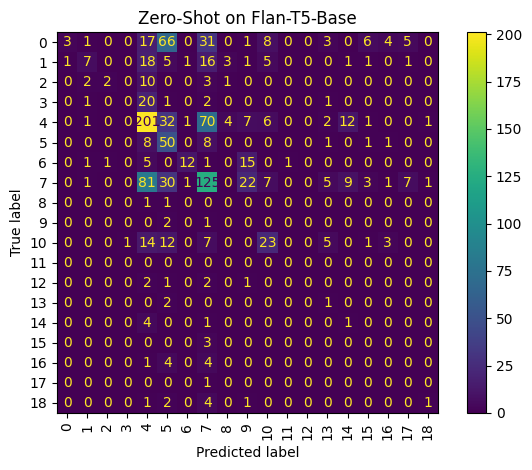

0: Action
1: Adventure
2: Animation
3: Children
4: Comedy
5: Crime
6: Documentary
7: Drama
8: Fantasy
9: Film-Noir
10: Horror
11: IMAX
12: Musical
13: Mystery
14: Romance
15: Sci-Fi
16: Thriller
17: War
18: Western


In [24]:
# Generate confusion matrix

# get mapping from labels to numbers in confusion matrix
label_enc = LabelEncoder()
true_enc = label_enc.fit_transform(y_train)
pred_enc = label_enc.transform(y_pred)
mapping = dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_)))

# create matrix
cm = confusion_matrix(y_test, y_pred, labels=label_enc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.title("Zero-Shot on Flan-T5-Base")
plt.tight_layout()
plt.savefig("./zero-shot-output/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

for i, genre in enumerate(label_enc.classes_):
    print(f"{i}: {genre}")
